## NEURON

In [1]:
import math
#math.sqrt(surf / math.pi)
surf=524.64e-8 # surface in cm^2 form neuromorpho VA5L
    
L=math.sqrt(surf/math.pi)
rsoma=L*1e4
print(rsoma)


12.922774419120067


array([ 3.81213785e-05,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.90606892e-04,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        2.47788960e-05, -5.20000000e+01,  1.00000000e+00,  1.50000000e+00])
soma { nseg=1  L=12.9228  Ra=100
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=12.9228}
	insert capacitance { cm=1.5}
}
All parameters used in current clamp:
soma { nseg=1  L=12.9228  Ra=100
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=12.9228}
	insert capacitance { cm=1.5}
	insert slo2egl19 { gbar_slo2egl19=0}
	insert slo1egl19 { gbar_slo1egl19=3.81214e-05}
	insert slo2unc2 { gbar_slo2unc2=0}
	insert slo1unc2 { gbar_slo1unc2=0}
	insert slo2iso { gbar_slo2iso=0 c2_slo2iso=1}
	insert slo1iso { gbar_slo1iso=0 c1_slo1iso=1}
	insert egl19 { gbar_egl19=0.000190607}
	insert unc2 { gbar_unc2=0}
	insert cca1 { gbar_c

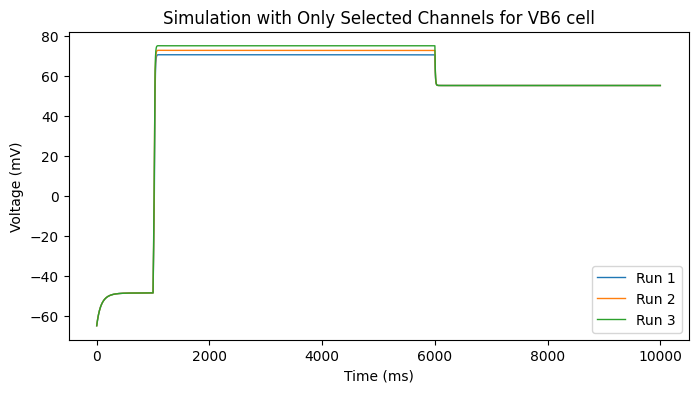

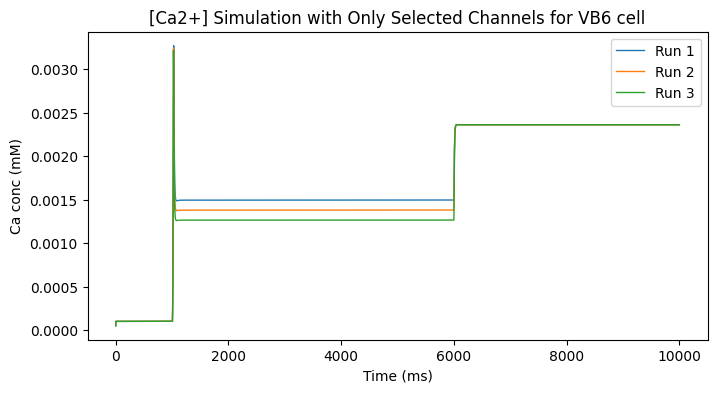

In [2]:

import sys
sys.path.append('..')  # the parent directory
from VB6_simulation_iclamp import VB6_simulation_iclamp
from g_to_Scm2 import gScm2
import pprint

surf=524.64e-8

# conductances: slo1EGL19,SLO2egl19,slo1unc2, SLO2unc2, SLO1ISO, SLO2ISO,egl19,unc2,cca1,IRK,shk1mix,nca,leak,eleak,c2,cm
g0=[0.2,1.75,1,1,1,2,0.1,0.1,0,1,0.4,0.03,0.13,-52,1,1.5]

# leak + egl19
g0=[0.2, # slo1EGL19 = 0.2 NOT WORKING
    0.0, # slo2EGL19 = 1.75 NOT WORKING
    0.0, # slo1unc2 = 1    NOT WORKING
    0.0,   # slo2unc2 = 1   NOT DONE 
    0.0, # slo1iso  = 1  DONE
    0.0, # slo2iso = 2   DONE
    1, # egl19 = 0.1   DONE
    0.0, # unc2 = 0.1   DONE
    0.0, # cca1 = 0    DONE
    0.0, # IRK = 1    DONE
    0.0, # shk1 = 0.4  DONE
    0.0, # nca = 0.03  DONE
    0.13, # leak = 0.13  DONE
    -52,1,1.5] # eleak, slo2iso.c2, cm
  
 

    
gVB6_scaled = gScm2(g0,surf,12)
pprint.pprint(gVB6_scaled)


v, time1, ca, soma, stim = VB6_simulation_iclamp(gVB6_scaled, s1=0.015, s2=0.019, ns=3, delay=1000, duration=5000, simdur = 10000, transient=0)
#s2 = 0.035
# best_cc=AIY_simulation_iclamp(gbest,-0.015,0.035,11)
# best_voltage=best_cc[0]
# best_time2=best_cc[1]
# best_VIss=best_cc[3]
# best_VIpeaks=best_cc[2]


# #Matplotlib

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
for i in range(len(v)):
    plt.plot(time1[i], v[i], label=f'Run {i + 1}', linewidth=1)
plt.title('Simulation with Only Selected Channels for VB6 cell')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.figure(figsize=(8, 4))

for i in range(len(ca)):
    plt.plot(time1[i], ca[i], label=f'Run {i + 1}', linewidth=1)
plt.title('[Ca2+] Simulation with Only Selected Channels for VB6 cell')
plt.xlabel('Time (ms)')
plt.ylabel('Ca conc (mM)')
plt.legend()

plt.show()

## NeuroML

In [3]:
import pandas as pd
from pyneuroml import pynml

def run_simulation_and_get_results(lems_file):
    # Run the simulation with pyNeuroML
    print(f"Running simulation: {lems_file}")
    results = pynml.run_lems_with_jneuroml(
        lems_file, 
        max_memory="1024M", 
        nogui=True, 
        plot=False, 
        load_saved_data=True
    )

    # time and variable values
    time = results["t"]
    voltage_data = {}
    ca_data = {}
    for key in results:
        if key.startswith("pop_VB6") and key.endswith("/v"):  # Filter voltage keys
            compartment = key.split("/")[1]  # Extract compartment index
            voltage_data[f"Run {compartment}"] = results[key]
        if key.startswith("pop_VB6") and key.endswith("/caConc"):  # Filter ca keys
            compartment = key.split("/")[1]  # Extract compartment index
            ca_data[f"Run {compartment}"] = results[key]
    
    
    df = pd.DataFrame(voltage_data)
    df.insert(0, "Time (ms)", time)  # Add time as the first column
    dfca = pd.DataFrame(ca_data)
    dfca.insert(0, "Time (ms)", time)  # Add time as the first column
    return df, dfca


lems_file = "LEMS_Sim_IClamp_VB6.xml" 
df_VB6_NML, dfca_VB6_NML = run_simulation_and_get_results(lems_file)
df_VB6_NML = df_VB6_NML * 1000 # Convert voltage from V to mV and time from s to ms
nml_time = df_VB6_NML.iloc[:, 0]
nml_voltages = df_VB6_NML.iloc[:, 1:4]


# fixing the ca columns: 
corrected_ca_columns = sorted(dfca_VB6_NML.columns[1:], key=lambda x: int(x.split()[-1])) 
dfca_VB6_NML = dfca_VB6_NML[['Time (ms)'] + corrected_ca_columns]  
nml_ca = dfca_VB6_NML.iloc[:, 1:4]




pyNeuroML >>> 21:30:08 - INFO - Loading LEMS file: LEMS_Sim_IClamp_VB6.xml and running with jNeuroML
pyNeuroML >>> 21:30:08 - INFO - Executing: (java -Xmx1024M  -Djava.awt.headless=true -jar  "/opt/homebrew/anaconda3/envs/py39n/lib/python3.9/site-packages/pyneuroml/utils/./../lib/jNeuroML-0.14.0-jar-with-dependencies.jar"  LEMS_Sim_IClamp_VB6.xml  -nogui -I '') in directory: .


Running simulation: LEMS_Sim_IClamp_VB6.xml


pyNeuroML >>> 21:31:11 - INFO - Command completed successfully!


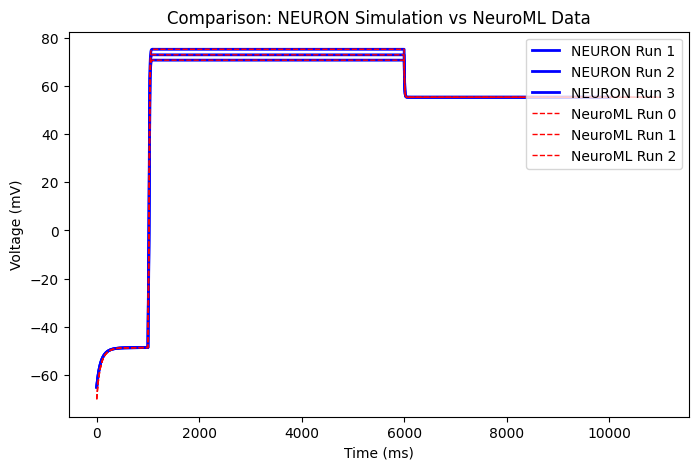

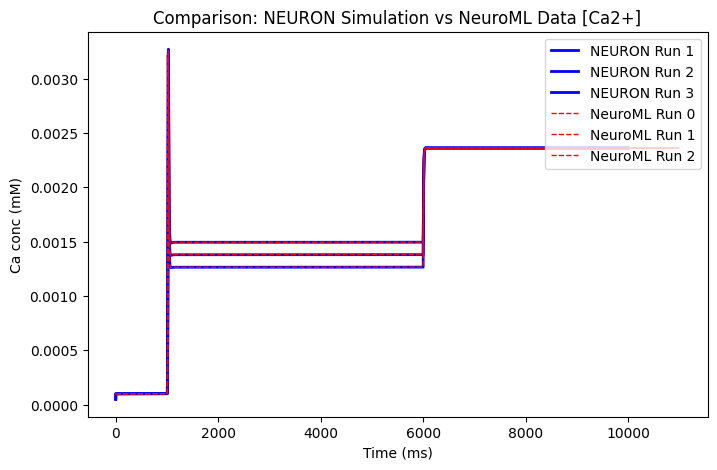

In [4]:
#matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# NEURON simulation data
for i in range(len(v)):
    plt.plot(time1[i], v[i], label=f'NEURON Run {i + 1}', linewidth=2, color='blue')

# NeuroML data
for col in nml_voltages.columns:
    plt.plot(nml_time, df_VB6_NML[col], label=f'NeuroML {col}', linewidth=1, color='red', linestyle='--')


plt.title('Comparison: NEURON Simulation vs NeuroML Data')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')

plt.legend(loc='upper right')

plt.figure(figsize=(8, 5))

# NEURON simulation data
for i in range(len(ca)):
    plt.plot(time1[i], ca[i], label=f'NEURON Run {i + 1}', linewidth=2, color='blue')

# NeuroML data
for col in nml_ca.columns:
    plt.plot(nml_time, dfca_VB6_NML[col], label=f'NeuroML {col}', linewidth=1, color='red', linestyle='--')


plt.title('Comparison: NEURON Simulation vs NeuroML Data [Ca2+]')
plt.xlabel('Time (ms)')
plt.ylabel('Ca conc (mM)')

plt.legend(loc='upper right')

plt.show()


In [5]:
# # PLOTLY
# import plotly.graph_objects as go

# # # Create the Plotly figure
# fig = go.Figure()

# # Add NEURON simulation data to the plot
# fig = go.Figure()

# for i in range(len(ca)):
#     fig.add_trace(
#         go.Scatter(
#             x=time1[i], 
#             y=ca[i], 
#             mode='lines', 
#             name=f'NEURON Run {i + 1}', # Label each run
#             line = dict(color = 'blue', width = 2)
#         )
#     )



# # Add NeuroML data to the plot
# for col in nml_voltages.columns:
#     fig.add_trace(
#         go.Scatter(
#             x=nml_time,  # Time from NeuroML data
#             y=dfca_VB6_NML[col],  # Voltage from NeuroML data
#             mode='lines',
#             name=f'NeuroML {col}',  # Label for each trace
#             line=dict(color='red', dash='dash', width=1)
#         )
#     )

# # Update layout for clarity
# fig.update_layout(
#     title='Comparison: NEURON Simulation vs NeuroML Data',
#     xaxis_title='Time (ms)',
#     yaxis_title='Voltage (mV)',
#     template='plotly_white',
#     legend=dict(x=0.99, y=0.99),  # Adjust legend position
#     height=600,  
#     width=800   
# )

# # Show the plot
# fig.show()
